# Weekly \#1


Adapted from a lab provided with Intro to Statistical Learning (with Python).

In [2]:
!pip install statsmodels ISLP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52/52 [ISLP]0m [ISLP]0m [pytorch_lightning]


In [2]:
#you will need all of these libraries installed before running this
#let me know if you need any help with that 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data


## Principal Components Analysis
PCA is a dimensionality reduction technique that allows us to represent our data using only the most informative features. In particular, PCA computes the directions (feature vectors) of greatest variance in the data (aka the principal components). These form an orthonormal basis of the feature space, and we can reduce the number of features used for learning by projecting onto only the first several components (corresponding to largest variance).


 We will perform PCA on  `USArrests`, a data set in the
`R` computing environment.
We retrieve the data using `get_rdataset()`, which can fetch data from
many standard `R` packages.

The rows of the data set contain the 50 states, in alphabetical order.

In [3]:
USArrests = get_rdataset('USArrests').data
USArrests

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


The columns of the data set contain the four variables.

In [5]:
USArrests.columns

Index(['Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

We first briefly examine the data. We notice that the variables have vastly different means.

In [6]:
USArrests.mean()

Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

Dataframes have several useful methods for computing
column-wise summaries. We can also examine the
variance of the four variables using the `var()`  method.

In [7]:
USArrests.var()


Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

Not surprisingly, the variables also have vastly different variances.
The `UrbanPop` variable measures the percentage of the population
in each state living in an urban area, which is not a comparable
number to the number of rapes in each state per 100,000 individuals.
PCA looks for derived variables that account for most of the variance in the data set.
If we do not scale the variables before performing PCA, then the principal components
would mostly be driven by the
`Assault` variable, since it has by far the largest
variance.  So if the variables are measured in different units or vary widely in scale, it is recommended to standardize the variables to have standard deviation one before performing PCA.
Typically we set the means to zero as well.

This scaling can be done via the `StandardScaler()` transform imported above. We first `fit` the
scaler, which computes the necessary means and standard
deviations and then apply it to our data using the
`transform` method. As before, we combine these steps using the `fit_transform()` method.


In [8]:
scaler = StandardScaler(with_std=True,
                        with_mean=True)
USArrests_scaled = scaler.fit_transform(USArrests)


Having scaled the data, we can then
perform principal components analysis using the `PCA()` transform
from the `sklearn.decomposition` package.

In [9]:
pcaUS = PCA()


(By default, the `PCA()`  transform centers the variables to have
mean zero though it does not scale them.) The transform `pcaUS`
can be used to find the PCA
`scores` returned by `fit()`. Once the `fit` method has been called, the `pcaUS` object also contains a number of useful quantities.

In [10]:
pcaUS.fit(USArrests_scaled)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

After fitting, the `mean_` attribute corresponds to the means
of the variables. In this case, since we centered and scaled the data with
`scaler()` the means will all be 0.

In [11]:
pcaUS.mean_


array([-7.10542736e-17,  1.38777878e-16, -4.39648318e-16,  8.59312621e-16])

Two notes: 
* The means are not exactly zero but are very close to zero. Computers do their best. 🤖
* There are four principal components, same as the original number of variables. We will talk about how to reduce the dimension later! 

The scores can be computed using the `transform()` method
of `pcaUS` after it has been fit.

In [12]:
scores = pcaUS.transform(USArrests_scaled)


We will plot these scores a bit further down.
The `components_` attribute provides the principal component **loadings**:
each row of `pcaUS.components_` contains the corresponding
principal component loading vector.

Note: The loadings are the covariances between the original variables and the unit-scaled components.


In [13]:
pcaUS.components_ 


array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

### Question 1
 **Explain the first row of the array printed above. Which original variable seems to contribute most to the variation in the data set?**


**The rows above describe the principal components as a linear combination of the original variables. The values are the coefficients of these linear combinations and describe to what extent the variable contributes to that component.
PC1 = 0.53murder + 0.58assault + 0.27urbanpop + .54rape**
 

The `biplot`  is a common visualization method used with
PCA. It is not built in as a standard
part of `sklearn`, though there are python
packages that do produce such plots. Here we
make a simple biplot manually.

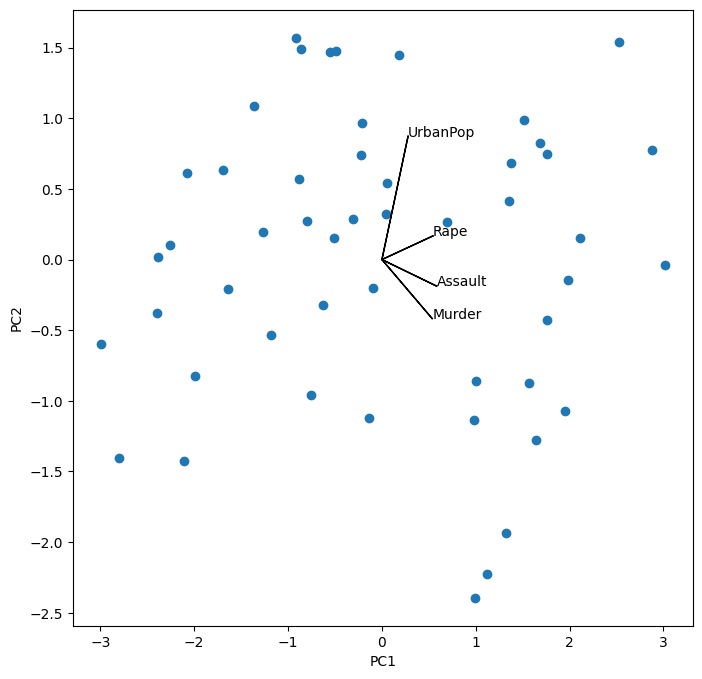

In [14]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, pcaUS.components_[i,k], pcaUS.components_[j,k])
    ax.text(pcaUS.components_[i,k],
            pcaUS.components_[j,k],
            USArrests.columns[k])


Notice that this figure is a reflection of Figure 12.1 (in the ISLP textbook) through the $y$-axis. Recall that the
principal components are only unique up to a sign change, so we can
reproduce that figure by flipping the
signs of the second set of scores and loadings.
We also increase the length of the arrows to emphasize the loadings.

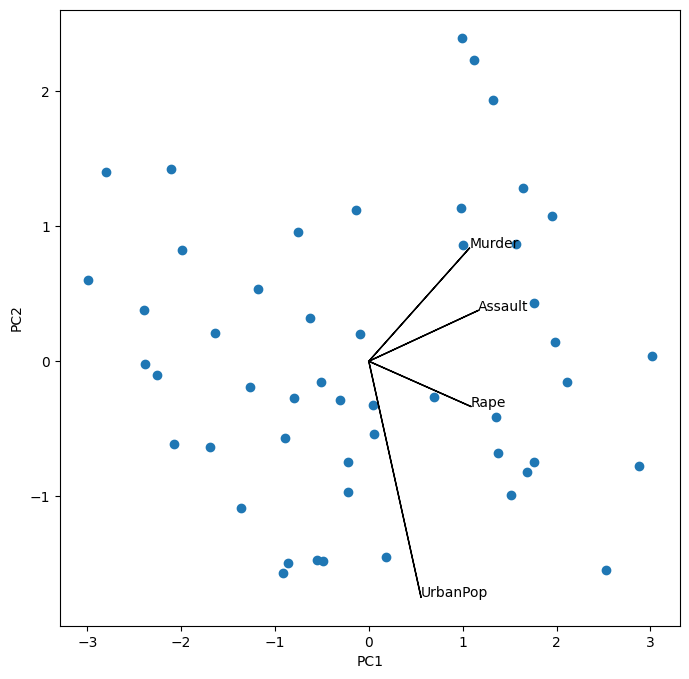

In [15]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pcaUS.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaUS.components_[i,k], s_*pcaUS.components_[j,k])
    ax.text(s_*pcaUS.components_[i,k],
            s_*pcaUS.components_[j,k],
            USArrests.columns[k])


The standard deviations of the principal component scores are as follows:

In [16]:
scores.std(0, ddof=1)

array([1.5908673 , 1.00496987, 0.6031915 , 0.4206774 ])

The variance of each score can be extracted directly from the `pcaUS` object via
the `explained_variance_` attribute.

In [17]:
pcaUS.explained_variance_


array([2.53085875, 1.00996444, 0.36383998, 0.17696948])

The proportion of variance explained by each principal 
component (PVE) is stored as `explained_variance_ratio_`:

In [18]:
pcaUS.explained_variance_ratio_


array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

### Question 2
**Explain the numbers printed above in your own words.**


**The proportion of variance explained by each principal component, e.g. PC1 explains 62\% of the variance**

We can plot the PVE explained by each component, as well as the cumulative PVE. We first
plot the proportion of variance explained.

In [19]:
%%capture
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pcaUS.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pcaUS.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)


Notice the use of `%%capture`, which suppresses the displaying of the partially completed figure.

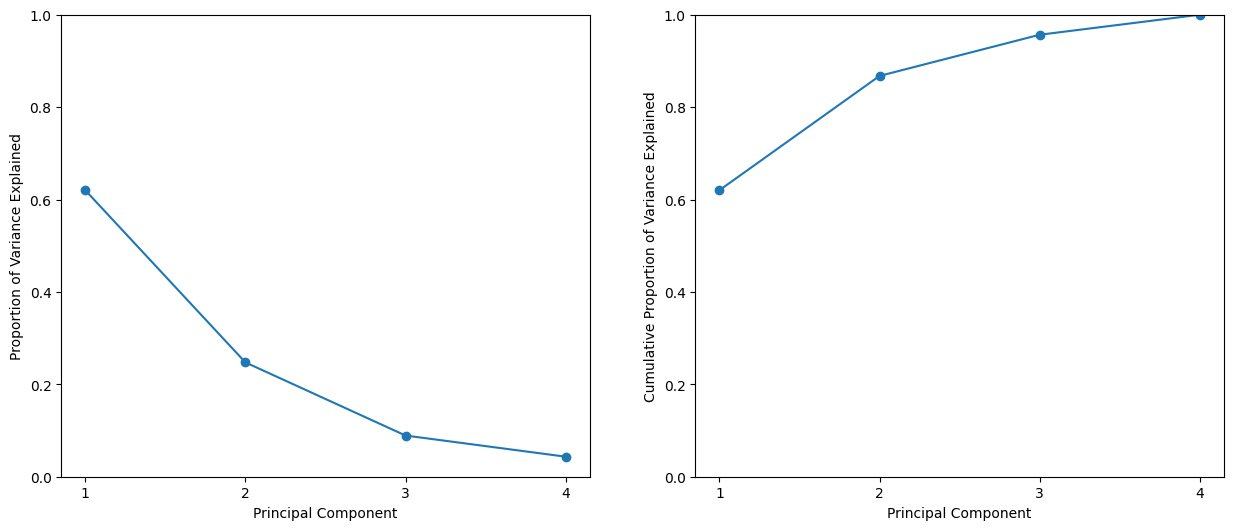

In [20]:
ax = axes[1]
ax.plot(ticks,
        pcaUS.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig


The result is similar to that shown in Figure 12.3.  Note
that the method `cumsum()`   computes the cumulative sum of
the elements of a numeric vector. For instance:

In [22]:
a = np.array([1,2,8,-3])
np.cumsum(a)


array([ 1,  3, 11,  8])

## NCI60 Data Example
Unsupervised techniques are often used in the analysis of genomic
data. In particular, PCA and hierarchical clustering are popular
tools.  We illustrate PCA on the `NCI60`  cancer cell line
microarray data, which consists of 6830 gene expression
measurements on 64 cancer cell lines.

In [23]:
NCI60 = load_data('NCI60')
nci_labs = NCI60['labels']
nci_data = NCI60['data']


Each cell line is labeled with a cancer type. We do not make use of
the cancer types in performing PCA and clustering, as these are
unsupervised techniques. But after performing PCA and clustering, we
will check to see the extent to which these cancer types agree with
the results of these unsupervised techniques.

The data has 64 rows and 6830 columns.

In [24]:
nci_data.shape


(64, 6830)

We begin by examining the cancer types for the cell lines.


In [25]:
nci_labs.value_counts()


label      
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64

### PCA on the NCI60 Data

We first perform PCA on the data after scaling the variables (genes)
to have standard deviation one, although here one could reasonably argue
that it is better not to scale the genes as they are measured in the same units.

In [26]:
scaler = StandardScaler()
nci_scaled = scaler.fit_transform(nci_data)
nci_pca = PCA()
nci_scores = nci_pca.fit_transform(nci_scaled)


We now plot the first few principal component score vectors, in order
to visualize the data. The observations (cell lines) corresponding to
a given cancer type will be plotted in the same color, so that we can
see to what extent the observations within a cancer type are similar
to each other. 

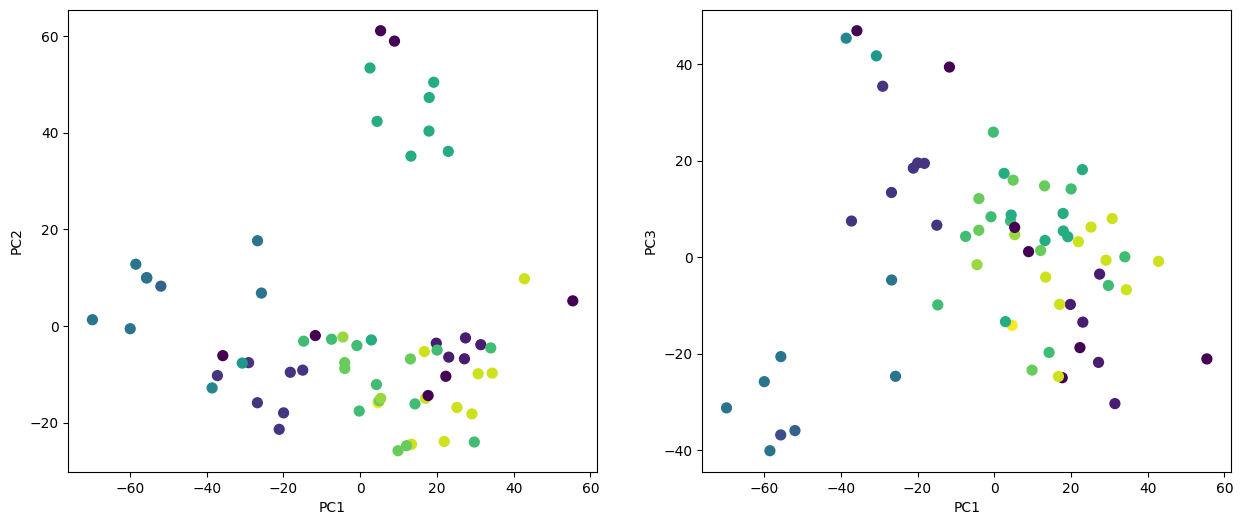

In [27]:
cancer_types = list(np.unique(nci_labs))
nci_groups = np.array([cancer_types.index(lab)
                       for lab in nci_labs.values])
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ax.scatter(nci_scores[:,0],
           nci_scores[:,1],
           c=nci_groups,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax = axes[1]
ax.scatter(nci_scores[:,0],
           nci_scores[:,2],
           c=nci_groups,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC3');


### Question 3

**Looking at the figures above, do the cancer types tend to have similar values on the first few principal component score vectors?**


**We see some clustering, though it varies among the types of cancer -- also note we are projecting down to two dimensions.** 

We can also plot the percent variance
explained by the principal components as well as the cumulative percent variance explained.
This is similar to the plots we made earlier for the `USArrests` data.

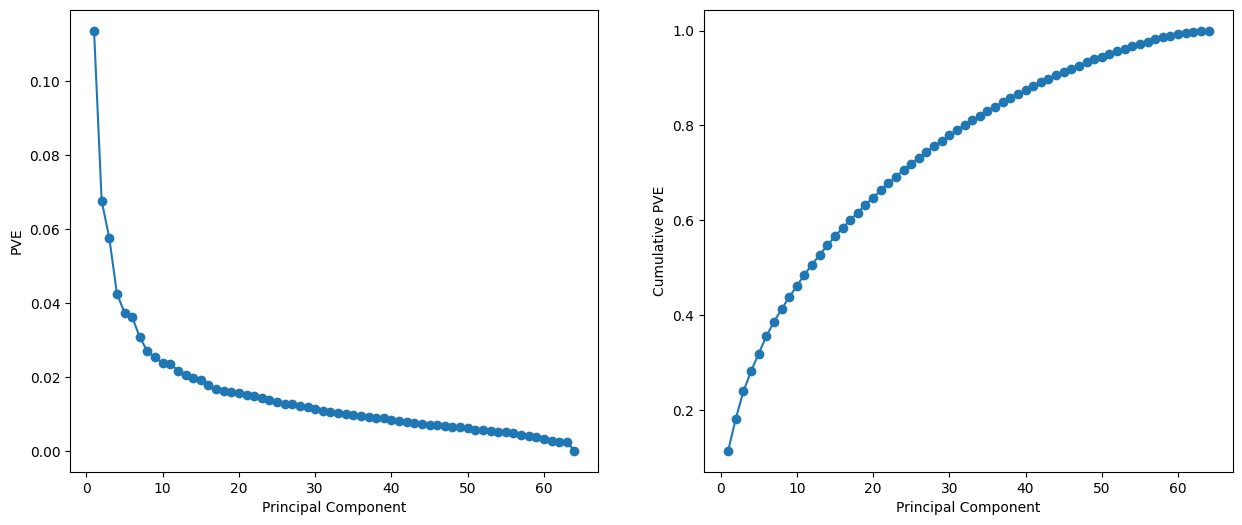

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ticks = np.arange(nci_pca.n_components_)+1
ax.plot(ticks,
        nci_pca.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('PVE')
ax = axes[1]
ax.plot(ticks,
        nci_pca.explained_variance_ratio_.cumsum(),
        marker='o');
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative PVE');


We see that together, the first seven principal components explain
around 40% of the variance in the data. This is not a huge amount
of the variance. However, looking at the scree plot, we see that while
each of the first seven principal components explain a substantial
amount of variance, there is a marked decrease in the variance
explained by further principal components. That is, there is an
*elbow*  in the plot after approximately the seventh
principal component. 

### Question 4
**How many principal components does the above suggest we should use to represent our data? How much of the variance do you think should be included in the final expression?**

This is just opinion.